### Import libraries.

In [36]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score

### Load the dataset.

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

In [16]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
77,5,95,72,33,0,37.7,0.370,27,0
408,8,197,74,0,0,25.9,1.191,39,1
276,7,106,60,24,0,26.5,0.296,29,1
538,0,127,80,37,210,36.3,0.804,23,0
244,2,146,76,35,194,38.2,0.329,29,0


In [17]:
X = df.iloc[ : , : 8]
y = df['Outcome']

In [18]:
# train test split. 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=13)

In [19]:
# standardise the dataset. 

# scaler = StandardScaler()
# X_train_trans = scaler.fit_transform(X_train)
# X_test_trans = scaler.transform(X_test)

In [22]:
# apply the models. 

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [37]:
print('Accuracy : ', accuracy_score(y_test, lr_model.predict(X_test)))

Accuracy :  0.7792207792207793


In [27]:
# check the classes for prob. 
lr_model.classes_

array([0, 1])

In [29]:
lr_model.predict_proba(X_test)

array([[0.71397947, 0.28602053],
       [0.76468337, 0.23531663],
       [0.87027939, 0.12972061],
       [0.63637423, 0.36362577],
       [0.56846454, 0.43153546],
       [0.97570716, 0.02429284],
       [0.90116422, 0.09883578],
       [0.74265198, 0.25734802],
       [0.64408916, 0.35591084],
       [0.31497557, 0.68502443],
       [0.79370091, 0.20629909],
       [0.88167839, 0.11832161],
       [0.85078883, 0.14921117],
       [0.12313059, 0.87686941],
       [0.92310909, 0.07689091],
       [0.16237931, 0.83762069],
       [0.80882859, 0.19117141],
       [0.75522916, 0.24477084],
       [0.33037316, 0.66962684],
       [0.76230082, 0.23769918],
       [0.86465372, 0.13534628],
       [0.87951649, 0.12048351],
       [0.64886827, 0.35113173],
       [0.43772777, 0.56227223],
       [0.91354723, 0.08645277],
       [0.6766659 , 0.3233341 ],
       [0.16030003, 0.83969997],
       [0.80122973, 0.19877027],
       [0.399302  , 0.600698  ],
       [0.15392802, 0.84607198],
       [0.

In [30]:
y_scores = lr_model.predict_proba(X_test)[ : , 1]

In [32]:
# this score is telling me the probability of comming 1.
y_scores

array([0.28602053, 0.23531663, 0.12972061, 0.36362577, 0.43153546,
       0.02429284, 0.09883578, 0.25734802, 0.35591084, 0.68502443,
       0.20629909, 0.11832161, 0.14921117, 0.87686941, 0.07689091,
       0.83762069, 0.19117141, 0.24477084, 0.66962684, 0.23769918,
       0.13534628, 0.12048351, 0.35113173, 0.56227223, 0.08645277,
       0.3233341 , 0.83969997, 0.19877027, 0.600698  , 0.84607198,
       0.8770264 , 0.21647247, 0.26334034, 0.29387889, 0.10885706,
       0.28367976, 0.80348187, 0.47111861, 0.09290267, 0.11261019,
       0.38758287, 0.19675151, 0.18599398, 0.18563457, 0.11570166,
       0.60514348, 0.66275676, 0.32927017, 0.32994342, 0.27418018,
       0.57748746, 0.31286803, 0.23525057, 0.14695151, 0.72182165,
       0.04146574, 0.37027606, 0.38820434, 0.59320376, 0.23038284,
       0.11654411, 0.22488636, 0.23909035, 0.76134897, 0.83432574,
       0.6962564 , 0.35700864, 0.13916542, 0.34941863, 0.31896085,
       0.78681089, 0.0430521 , 0.07317345, 0.27269057, 0.16449

In [43]:
# find the fpr, tpr, and thresholds. 

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

In [44]:
fpr

array([0.        , 0.01030928, 0.01030928, 0.02061856, 0.02061856,
       0.04123711, 0.04123711, 0.05154639, 0.05154639, 0.06185567,
       0.06185567, 0.07216495, 0.07216495, 0.09278351, 0.09278351,
       0.12371134, 0.12371134, 0.15463918, 0.15463918, 0.17525773,
       0.17525773, 0.19587629, 0.19587629, 0.20618557, 0.20618557,
       0.21649485, 0.21649485, 0.22680412, 0.22680412, 0.24742268,
       0.24742268, 0.26804124, 0.26804124, 0.32989691, 0.32989691,
       0.39175258, 0.39175258, 0.45360825, 0.45360825, 0.48453608,
       0.48453608, 0.50515464, 0.50515464, 0.55670103, 0.55670103,
       0.57731959, 0.57731959, 0.59793814, 0.59793814, 0.60824742,
       0.60824742, 0.67010309, 0.67010309, 1.        ])

In [45]:
tpr

array([0.        , 0.        , 0.19298246, 0.19298246, 0.24561404,
       0.24561404, 0.36842105, 0.36842105, 0.40350877, 0.40350877,
       0.42105263, 0.42105263, 0.56140351, 0.56140351, 0.57894737,
       0.57894737, 0.59649123, 0.59649123, 0.64912281, 0.64912281,
       0.66666667, 0.66666667, 0.70175439, 0.70175439, 0.73684211,
       0.73684211, 0.77192982, 0.77192982, 0.78947368, 0.78947368,
       0.80701754, 0.80701754, 0.8245614 , 0.8245614 , 0.84210526,
       0.84210526, 0.85964912, 0.85964912, 0.87719298, 0.87719298,
       0.89473684, 0.89473684, 0.9122807 , 0.9122807 , 0.92982456,
       0.92982456, 0.94736842, 0.94736842, 0.96491228, 0.96491228,
       0.98245614, 0.98245614, 1.        , 1.        ])

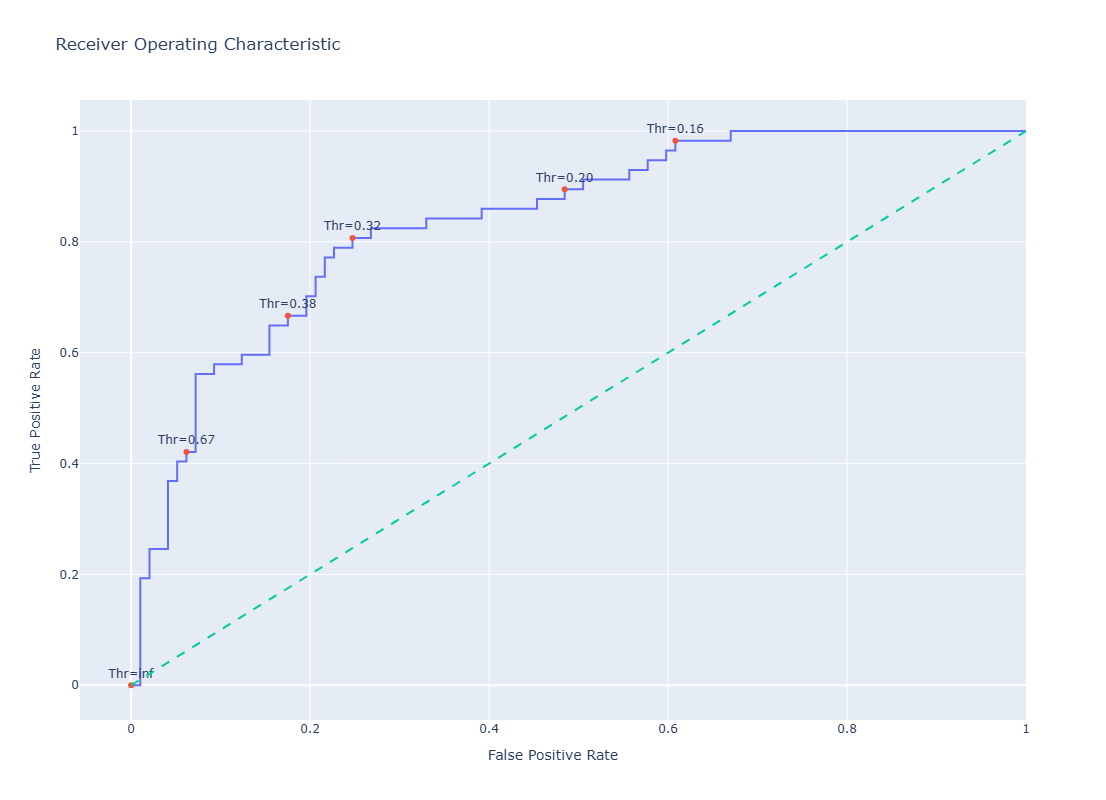

In [46]:
import plotly.graph_objects as go
import numpy as np


# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC curve'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [48]:
np.argmax(tpr - fpr)

np.int64(28)

In [49]:
tpr - fpr

array([ 0.        , -0.01030928,  0.18267318,  0.1723639 ,  0.22499548,
        0.20437692,  0.32718394,  0.31687466,  0.35196238,  0.3416531 ,
        0.35919696,  0.34888768,  0.48923856,  0.46862   ,  0.48616386,
        0.45523603,  0.47277989,  0.44185205,  0.49448363,  0.47386508,
        0.49140893,  0.47079038,  0.5058781 ,  0.49556882,  0.53065654,
        0.52034726,  0.55543498,  0.5451257 ,  0.56266956,  0.542051  ,
        0.55959486,  0.53897631,  0.55652017,  0.4946645 ,  0.51220836,
        0.45035269,  0.46789655,  0.40604088,  0.42358474,  0.3926569 ,
        0.41020076,  0.3895822 ,  0.40712606,  0.35557967,  0.37312353,
        0.35250497,  0.37004883,  0.34943028,  0.36697414,  0.35666486,
        0.37420872,  0.31235305,  0.32989691,  0.        ])

In [50]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.3361067692303949


In [51]:
### Compare two models.

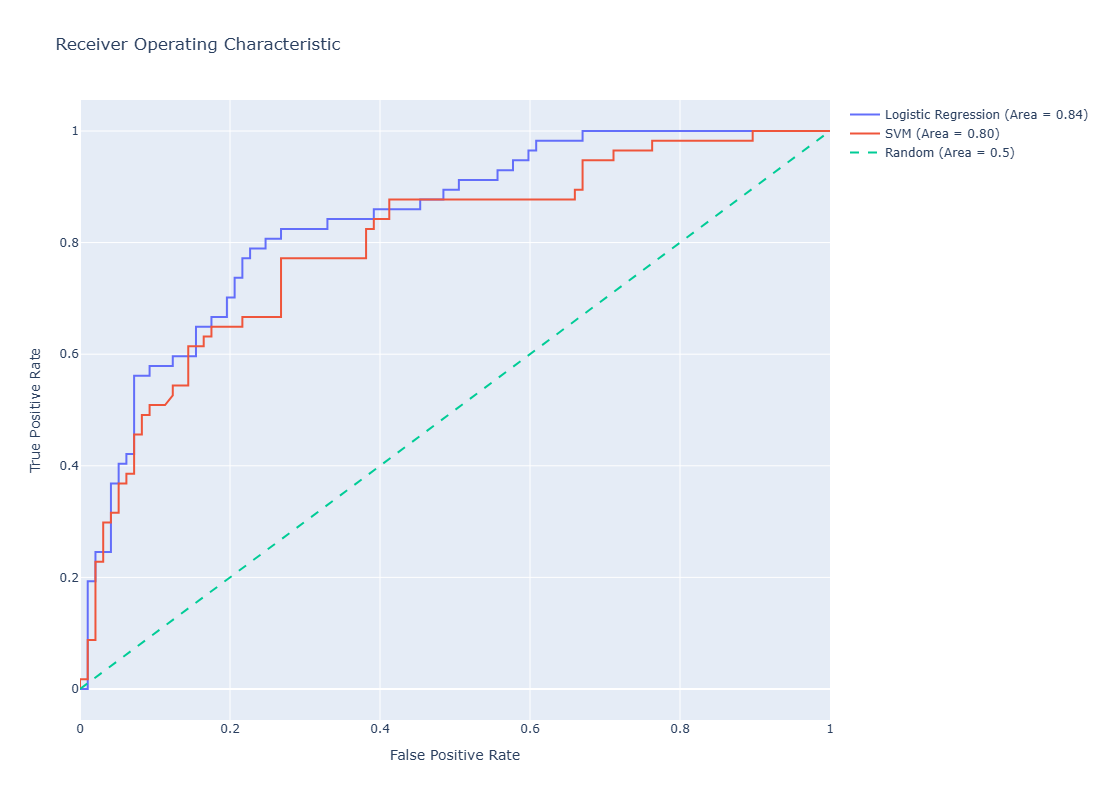

In [52]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()
